In [1]:
import numpy as np
import pandas as pd

from statsmodels.tsa.api import adfuller, kpss, range_unit_root_test

import pandas_datareader.data as web

# настройки визуализации
import matplotlib.pyplot as plt

# Не показывать Warnings
import warnings
warnings.simplefilter(action='ignore', category=Warning)

# 3.2.2

In [2]:
y = np.log(web.DataReader(name='M2SL', data_source='fred', start='1995-1'))
y

,M2SL
DATE,
1995-01-01,8.158344
1995-02-01,8.157628
1995-03-01,8.157972
1995-04-01,8.160290
1995-05-01,8.167409
...,...
2025-09-01,10.007334
2025-10-01,10.010551
2025-11-01,10.011485


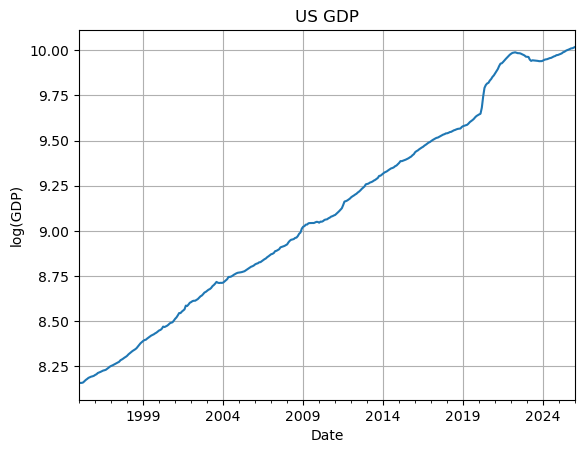

In [3]:
ax = y.plot(title='US GDP')

# надпись по ос oX
ax.set_xlabel('Date')
# надпись по ос oY
ax.set_ylabel('log(GDP)')
# отобразить сетку
ax.grid()
# удалим легенду
ax.legend().remove()

plt.show()

Тест ADF (Augmented Dickey-Fuller)
Нулевая гипотеза H0: наличие единичного корня (нестационарность, ряд I(1)). Альтернатива H1: стационарность (I(0)).

Отклонение H0 (p-value < 0.05 или статистика < критического значения) указывает на стационарность. Если не отклоняется, ряд нестационарен — требуется дифференцирование.

In [4]:
adf_stat, pval, usedlag, nobs, critical_values, BIC = adfuller(y, regression='ct', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat, pval, critical_values

(np.float64(-2.2216435211327576),
 np.float64(0.4776791536813571),
 {'1%': np.float64(-3.9833810512403542),
  '5%': np.float64(-3.4223904998647696),
  '10%': np.float64(-3.1340482267162413)})

p-value > 0.05
Ряд нестационарен. Нужно дифференцирование

In [5]:
adf_stat, pval, usedlag, nobs, critical_values, BIC = adfuller(y.diff().dropna(), regression='c', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat, pval, critical_values

(np.float64(-9.513751355680679),
 np.float64(3.197822912256566e-16),
 {'1%': np.float64(-3.4480996560263386),
  '5%': np.float64(-2.8693621113224137),
  '10%': np.float64(-2.570937038891028)})

p-value < 0.05 Ряд стационарен.

I = 1

Тест KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
Нулевая гипотеза H0: стационарность (уровень или с трендом). Альтернатива H1: нестационарность (единичный корень).

Не отклонение H0 (p-value > 0.05) подтверждает стационарность. Отклонение H0 говорит о нестационарности.


In [6]:
kpss_stat, p_value, lags, crit = kpss(y, regression='ct')
# тестовая статистика, её p-значение и критические значения
kpss_stat, p_value, crit

(np.float64(0.1373885344731646),
 np.float64(0.0659471583830285),
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

p-value > 0.05 Ряд стационарен. Противоречие с ADF

In [7]:
kpss_stat, p_value, lags, crit = kpss(y.diff().dropna(), regression='c')
# тестовая статистика, её p-значение и критические значения
kpss_stat, p_value, crit

(np.float64(0.07165974103451084),
 np.float64(0.1),
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

p-value > 0.05 Ряд стационарен. I = 1

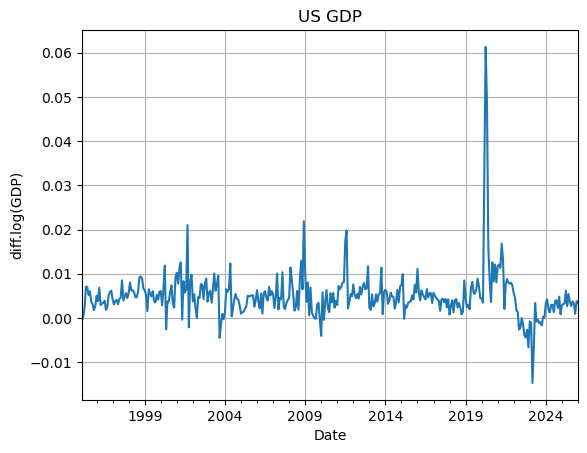

In [8]:
ax = y.diff().dropna().plot(title='US GDP')

# надпись по ос oX
ax.set_xlabel('Date')
# надпись по ос oY
ax.set_ylabel('diff.log(GDP)')
# отобразить сетку
ax.grid()
# удалим легенду
ax.legend().remove()

plt.show()

In [9]:
from statsmodels.tsa.stattools import arma_order_select_ic

In [10]:
# Используем информационные критерии AIC, AICC, BIC, HQIC
res = arma_order_select_ic(y.diff().dropna(), max_ar=4, max_ma=4, ic=['aic', 'aicc', 'bic', 'hqic'], trend='c')

In [11]:
# значения критерия AIC по всем моделям
res.aic

,0,1,2,3,4
0,-2810.097053,-2948.524091,-2963.540108,-2981.769715,-2979.680420
1,-2979.465029,-2978.605003,-2979.729915,-2977.535654,-2977.535381
2,-2978.364633,-2977.861870,-2978.895251,-2975.647053,-2973.094023
3,-2978.055099,-2977.063692,-2976.073169,-2975.629097,-2982.884843
4,-2976.305828,-2975.944230,-2974.617211,-2974.351563,-2980.549629


In [12]:
# оптимальный порядок по AIC
res.aic_min_order

(np.int64(3), np.int64(4))

In [13]:
# оптимальный порядок по AICc
res.aicc_min_order

(np.int64(3), np.int64(4))

In [14]:
# оптимальный порядок по BIC
res.bic_min_order

(np.int64(1), np.int64(0))

In [15]:
# оптимальный порядок по HQIC
res.hqic_min_order

(np.int64(1), np.int64(0))

In [16]:
# импорт из пакета pmdarima
from sktime.forecasting.arima import AutoARIMA

from sktime.utils.plotting import plot_series
# временной горизонт для прогнозирования
from sktime.forecasting.base import ForecastingHorizon

In [17]:
forecaster = AutoARIMA(information_criterion='bic', test='adf', seasonal=False)
forecaster.fit(y)
forecaster.get_fitted_params() #['order']

{'intercept': np.float64(0.0019451432304521017),
 'ar.L1': np.float64(0.607394096827675),
 'sigma2': np.float64(1.9099654016466338e-05),
 'order': (1, 1, 0),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-2979.4649744747835),
 'aicc': np.float64(-2979.399757083479),
 'bic': np.float64(-2967.7082929119642),
 'hqic': np.float64(-2974.7960769798005)}

In [18]:
forecaster = AutoARIMA(information_criterion='aic', test='adf', seasonal=True)
forecaster.fit(y)
forecaster.get_fitted_params() #['order']

{'intercept': np.float64(0.0019451432304521017),
 'ar.L1': np.float64(0.607394096827675),
 'sigma2': np.float64(1.9099654016466338e-05),
 'order': (1, 1, 0),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-2979.4649744747835),
 'aicc': np.float64(-2979.399757083479),
 'bic': np.float64(-2967.7082929119642),
 'hqic': np.float64(-2974.7960769798005)}

Оптимальная модель ARIMA - 1, 1, 0

# 3.2.4

In [19]:
y = np.log(web.DataReader(name='M2SL', data_source='fred', start='2000-1'))
y

,M2SL
DATE,
2000-01-01,8.448400
2000-02-01,8.451246
2000-03-01,8.457804
2000-04-01,8.469640
2000-05-01,8.467099
...,...
2025-09-01,10.007334
2025-10-01,10.010551
2025-11-01,10.011485


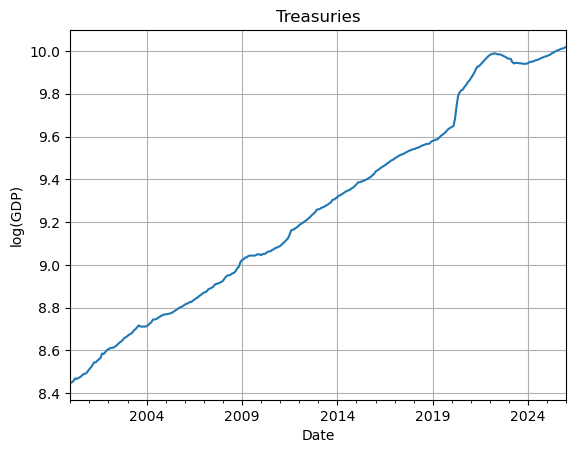

In [20]:
ax = y.plot(title='Treasuries')

# надпись по ос oX
ax.set_xlabel('Date')
# надпись по ос oY
ax.set_ylabel('log(GDP)')
# отобразить сетку
ax.grid()
# удалим легенду
ax.legend().remove()

plt.show()

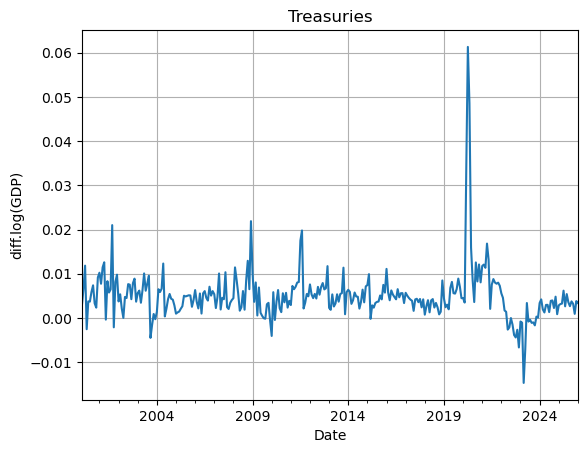

In [21]:
ax = y.diff().dropna().plot(title='Treasuries')

# надпись по ос oX
ax.set_xlabel('Date')
# надпись по ос oY
ax.set_ylabel('diff.log(GDP)')
# отобразить сетку
ax.grid()
# удалим легенду
ax.legend().remove()

plt.show()

In [22]:
adf_stat, pval, usedlag, nobs, critical_values, BIC = adfuller(y, regression='ct', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat, pval, critical_values

(np.float64(-2.0081705621219843),
 np.float64(0.5969758891878951),
 {'1%': np.float64(-3.988178023764844),
  '5%': np.float64(-3.4247019735849102),
  '10%': np.float64(-3.1354051510159615)})

p-value > 0.05 Ряд нестационарен. Нужно дифференцирование

In [23]:
adf_stat, pval, usedlag, nobs, critical_values, BIC = adfuller(y.diff().dropna(), regression='c', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat, pval, critical_values

(np.float64(-8.650327606896303),
 np.float64(5.136139609179603e-14),
 {'1%': np.float64(-3.451552879535732),
  '5%': np.float64(-2.8708786756338407),
  '10%': np.float64(-2.571745666091128)})

p-value < 0.05 Ряд стационарен.

In [24]:
kpss_stat, p_value, lags, crit = kpss(y, regression='ct')
# тестовая статистика, её p-значение и критические значения
kpss_stat, p_value, crit

(np.float64(0.15616735459750386),
 np.float64(0.04152720450208011),
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

p-value < 0.05 Ряд нестационарен. Нужно дифференцирование

In [25]:
kpss_stat, p_value, lags, crit = kpss(y.diff().dropna(), regression='c')
# тестовая статистика, её p-значение и критические значения
kpss_stat, p_value, crit

(np.float64(0.0934491287252087),
 np.float64(0.1),
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

p-value > 0.05 Ряд стационарен. I = 1

In [26]:
res = arma_order_select_ic(y.diff().dropna(), max_ar=4, max_ma=4, ic=['aic', 'aicc', 'bic', 'hqic'], trend='c')

In [27]:
# оптимальный порядок по AIC
res.aic_min_order

(np.int64(0), np.int64(3))

In [28]:
# оптимальный порядок по AICc
res.aicc_min_order

(np.int64(0), np.int64(3))

In [29]:
# оптимальный порядок по BIC
res.bic_min_order

(np.int64(1), np.int64(0))

In [30]:
# оптимальный порядок по HQIC
res.hqic_min_order

(np.int64(1), np.int64(0))

In [31]:
forecaster = AutoARIMA(information_criterion='bic', test='adf', seasonal=False)
forecaster.fit(y)
forecaster.get_fitted_params() #['order']

{'intercept': np.float64(0.001953268295336384),
 'ar.L1': np.float64(0.6101899257583957),
 'sigma2': np.float64(2.21702745177254e-05),
 'order': (1, 1, 0),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-2451.042538200443),
 'aicc': np.float64(-2450.9646161225205),
 'bic': np.float64(-2439.8135286370143),
 'hqic': np.float64(-2446.5546445386863)}

In [32]:
forecaster = AutoARIMA(information_criterion='aic', test='adf', seasonal=True)
forecaster.fit(y)
forecaster.get_fitted_params() #['order']

{'intercept': np.float64(0.001953268295336384),
 'ar.L1': np.float64(0.6101899257583957),
 'sigma2': np.float64(2.21702745177254e-05),
 'order': (1, 1, 0),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-2451.042538200443),
 'aicc': np.float64(-2450.9646161225205),
 'bic': np.float64(-2439.8135286370143),
 'hqic': np.float64(-2446.5546445386863)}

Оптимальная модель ARIMA - 1, 1, 0